## Supply Chain Analytics Project

This project delves into a comprehensive Supply Chain Dataset to uncover critical insights and optimize operational efficiency. Leveraging advanced data cleaning, feature engineering, and KPI analysis, the objective is to transform raw data into actionable intelligence. Key aspects include:

*   **Robust Data Quality Management**: Thorough assessment and handling of missing values and duplicates to ensure data integrity.
*   **Strategic Feature Engineering**: Creation of impactful features such as `Shipment_Delay`, `Delivery_Performance`, `Profit_Margin_%`, and `Order_Value_Category` to enrich the dataset for deeper analysis.
*   **Performance Metrics & KPIs**: Derivation of key performance indicators to monitor and evaluate supply chain efficiency and profitability.
*   **Data Standardization**: Application of consistent formatting across critical categorical variables for reliable analysis.

This analytical framework provides a solid foundation for further modeling and strategic decision-making, aiming to enhance customer satisfaction and drive business growth.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving DataCoSupplyChainDataset.csv to DataCoSupplyChainDataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("DataCoSupplyChainDataset.csv",
                 encoding='latin1')
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df.head()

df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


Data Quality Assessment


In [ ]:
quality_report = pd.DataFrame()

quality_report['Missing Values'] = df.isnull().sum()

quality_report['Missing %'] = (
    df.isnull().sum() / len(df)
) * 100

quality_report['Data Type'] = df.dtypes

In [ ]:
quality_report.sort_values(
    by='Missing %',
    ascending=False
)

,Missing Values,Missing %,Data Type
Product Description,180519,100.000000,float64
Order Zipcode,155679,86.239676,float64
Customer Lname,8,0.004432,object
Customer Zipcode,3,0.001662,float64
Days for shipment (scheduled),0,0.000000,int64
Sales per customer,0,0.000000,float64
Benefit per order,0,0.000000,float64
Delivery Status,0,0.000000,object
Late_delivery_risk,0,0.000000,int64
Customer City,0,0.000000,object


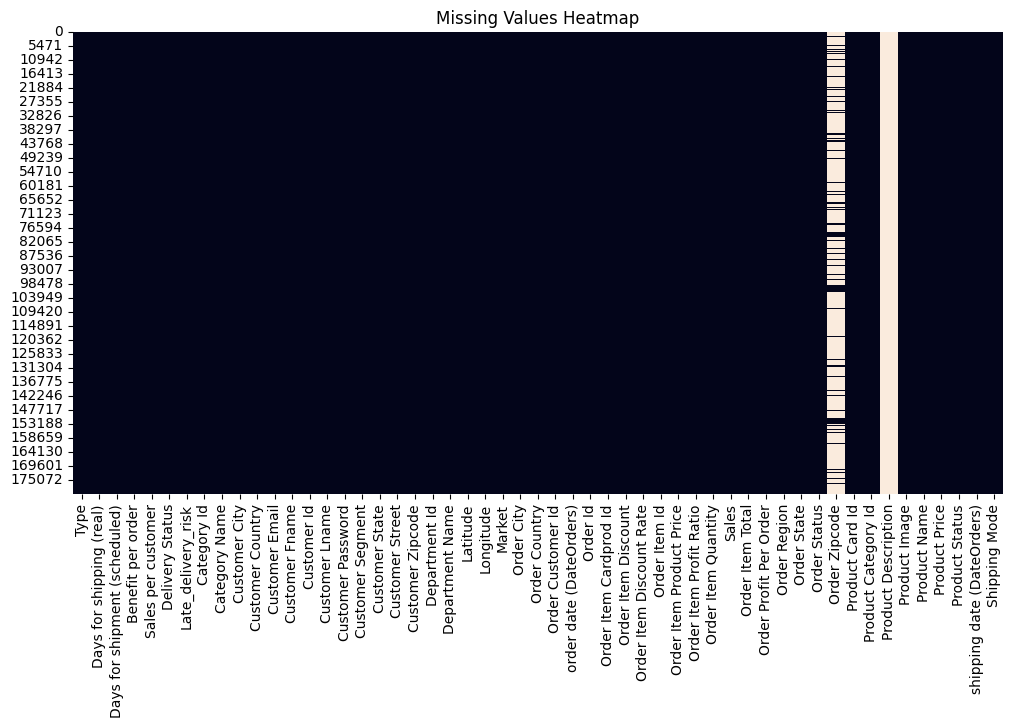

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.show()

In [ ]:
df['Customer Lname'].fillna(
    df['Customer Lname'].mode()[0],
    inplace=True
)

In [ ]:
duplicates = df.duplicated().sum()

print(duplicates)
df.drop_duplicates(
    inplace=True
)

0


In [ ]:
df['Shipment_Delay'] = (
    df['Days for shipping (real)']
    -
    df['Days for shipment (scheduled)']
)

In [ ]:
df['Delivery_Performance'] = np.where(
    df['Shipment_Delay'] > 0,
    'Delayed',
    'On Time'
)

In [ ]:
df['Profit_Margin_%'] = (
    df['Benefit per order']
    /
    df['Sales per customer']
) * 100

In [ ]:
df['Order_Value_Category'] = pd.qcut(
    df['Sales per customer'],
    q=4,
    labels=[
        'Low',
        'Medium',
        'High',
        'Premium'
    ]
)

In [ ]:
invalid_sales = df[
    df['Sales per customer'] < 0
]

print(len(invalid_sales))

0


In [ ]:
invalid_qty = df[
    df['Order Item Quantity'] <= 0
]

print(len(invalid_qty))

0


In [ ]:
invalid_price = df[
    df['Order Item Product Price'] < 0
]

print(len(invalid_price))

0


In [ ]:
invalid_discount = df[
    (df['Order Item Discount Rate'] < 0)
    |
    (df['Order Item Discount Rate'] > 1)
]

In [ ]:
text_cols = [
    'Delivery Status',
    'Customer Country',
    'Category Name',
    'Market',
    'Type'
]

for col in text_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.title()
    )

In [ ]:
total_cells = df.shape[0] * df.shape[1]

missing_pct = (
    df.isnull().sum().sum()
    /
    total_cells
)

duplicate_pct = (
    df.duplicated().sum()
    /
    len(df)
)

quality_score = (
    (1-missing_pct)*50 +
    (1-duplicate_pct)*50
)*100

print(
    f"Data Quality Score: {quality_score:.2f}"
)

Data Quality Score: 9836.63


In [ ]:
kpis = {
    'Total Orders':
        df['Order Id'].nunique(),

    'Total Customers':
        df['Customer Id'].nunique(),

    'Average Sales':
        round(
            df['Sales per customer'].mean(),
            2
        ),

    'Average Profit':
        round(
            df['Benefit per order'].mean(),
            2
        ),

    'Delayed Orders':
        len(
            df[
                df['Shipment_Delay'] > 0
            ]
        ),

    'Late Delivery Risk %':
        round(
            df['Late_delivery_risk'].mean()*100,
            2
        )
}

pd.DataFrame(
    kpis.items(),
    columns=['Metric','Value']
)

,Metric,Value
0,Total Orders,65752.00
1,Total Customers,20652.00
2,Average Sales,183.11
3,Average Profit,21.97
4,Delayed Orders,103400.00
5,Late Delivery Risk %,54.83


### Data Visualizations

To better understand the supply chain dynamics, let's visualize some of the key engineered features and performance indicators.

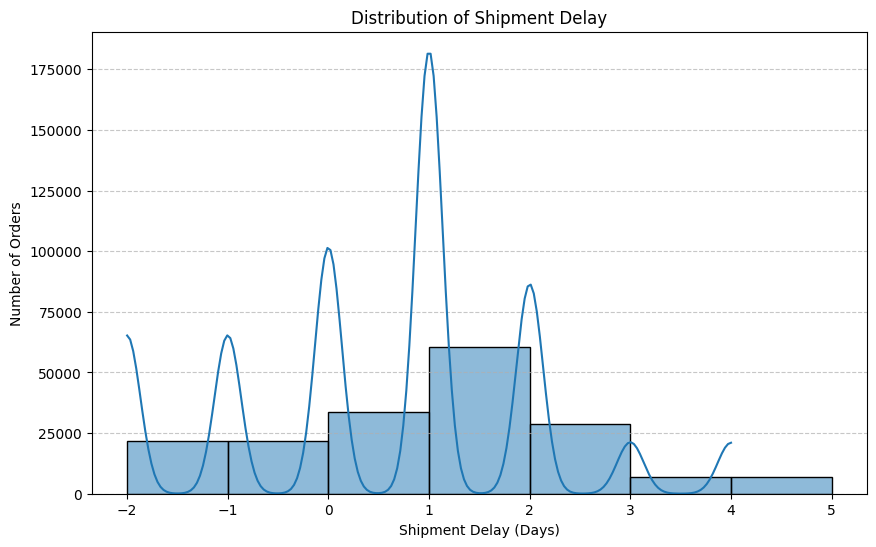

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Shipment_Delay'], bins=range(int(df['Shipment_Delay'].min()), int(df['Shipment_Delay'].max()) + 2), kde=True)
plt.title('Distribution of Shipment Delay')
plt.xlabel('Shipment Delay (Days)')
plt.ylabel('Number of Orders')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

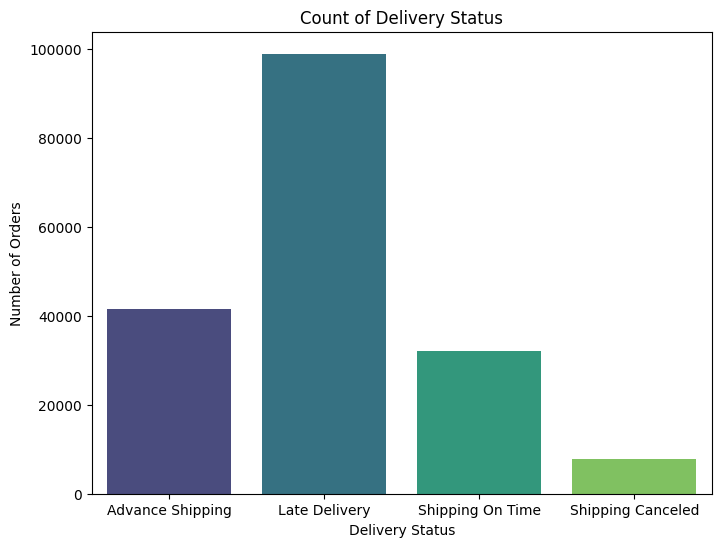

In [30]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Delivery Status', data=df, palette='viridis', hue='Delivery Status', legend=False)
plt.title('Count of Delivery Status')
plt.xlabel('Delivery Status')
plt.ylabel('Number of Orders')
plt.show()

In [ ]:
def clean_supply_chain_data(df):

    # Drop irrelevant columns
    drop_cols = [
        'Product Description',
        'Order Zipcode',
        'Customer Email',
        'Customer Password',
        'Customer Fname',
        'Customer Lname',
        'Customer Street'
    ]

    df = df.drop(columns=drop_cols)

    # Missing Values
    df['Customer Zipcode'].fillna(
        df['Customer Zipcode'].median(),
        inplace=True
    )

    # Duplicates
    df.drop_duplicates(inplace=True)

    # Date Conversion
    df['order date (DateOrders)'] = pd.to_datetime(
        df['order date (DateOrders)']
    )

    # Feature Engineering
    df['Shipment_Delay'] = (
        df['Days for shipping (real)']
        -
        df['Days for shipment (scheduled)']
    )

    df['Profit_Margin_%'] = (
        df['Benefit per order']
        /
        df['Sales per customer']
    ) * 100

    return df